In [1]:
!python -V

Python 3.12.6


In [2]:
import os
import sys

# Add the project root (1 level up from the notebook) to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)


In [3]:
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.metrics import root_mean_squared_error
from utils import download_files, read_dataframe, save_model

In [4]:
files_path = [
    './data/green_tripdata_2021-01.parquet',
    './data/green_tripdata_2021-02.parquet'
    ]
urls = [
    'https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-01.parquet',
    'https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-02.parquet'
    ]

In [5]:
download_files(files_path, urls)

File found locally at ./data/green_tripdata_2021-01.parquet.
File found locally at ./data/green_tripdata_2021-02.parquet.


In [8]:
df = pd.read_parquet(files_path[0])

df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [9]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

9.838799799829626

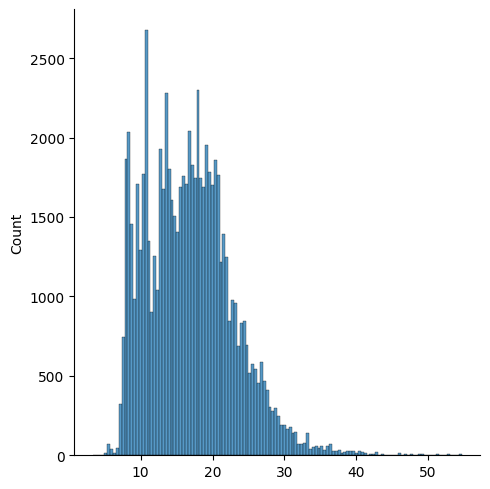

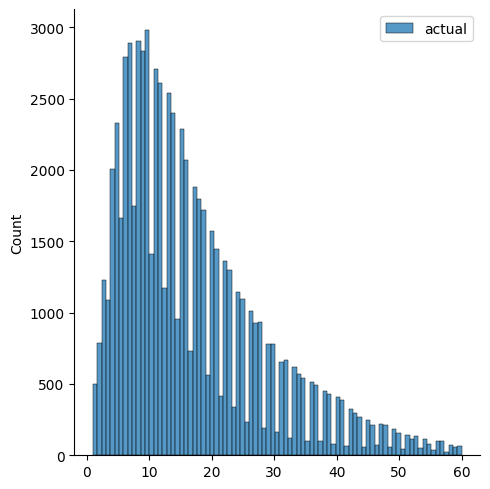

In [10]:
sns.displot(y_pred, label='prediction')
sns.displot(y_train, label='actual')

plt.legend()

In [ ]:
df_train = read_dataframe(files_path[0])
df_val = read_dataframe(files_path[1])

In [ ]:
len(df_train), len(df_val)

(73908, 61921)

In [ ]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [ ]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [ ]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.758714882773319

In [ ]:
save_model((dv, lr), 'models/lin_reg.bin')

Model saved to models/lin_reg.bin


In [ ]:
lr = Lasso(0.01)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

11.167275941179728